<a href="https://colab.research.google.com/github/devikapranesh/Scafolded-Project_DL/blob/main/ScafoldedProject3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.manifold import TSNE
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving UCI HAR Dataset.zip to UCI HAR Dataset.zip


In [ ]:
zip_path = "UCI HAR Dataset.zip"
import zipfile
import os

zip_path = "UCI HAR Dataset.zip"   # 👈 exact name from upload
extract_path = "/content/HAR"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Done:", os.listdir(extract_path))

Done: ['__MACOSX', 'UCI HAR Dataset']


In [ ]:
# Define paths (adjust folder name if different inside zip)
base_path = extract_path + "/UCI HAR Dataset/"

X_train = np.loadtxt(base_path + "train/X_train.txt")
y_train = np.loadtxt(base_path + "train/y_train.txt")

X_test = np.loadtxt(base_path + "test/X_test.txt")
y_test = np.loadtxt(base_path + "test/y_test.txt")

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (7352, 561)
Test Shape: (2947, 561)


In [ ]:
from sklearn.preprocessing import MinMaxScaler

# ✅ Step 1: make sure data is 2D BEFORE scaling
print("Before scaling:", X_train.shape)

# If already 3D → convert back to 2D
if len(X_train.shape) == 3:
    X_train = X_train.reshape(X_train.shape[0], X_train.shape[2])
    X_test  = X_test.reshape(X_test.shape[0], X_test.shape[2])

# ✅ Step 2: Scale
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("After scaling:", X_train.shape)  # (7352, 561)

# ✅ Step 3: Reshape for LSTM
X_train = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_test  = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])

print("Final shape:", X_train.shape)  # (7352, 1, 561)

Before scaling: (7352, 1, 561)
After scaling: (7352, 561)
Final shape: (7352, 1, 561)


In [ ]:
# Build Autoencoder (Rubric: Architecture ✔)
timesteps = X_train.shape[1]
features = X_train.shape[2]

inputs = Input(shape=(timesteps, features))

# Encoder
encoder = LSTM(128, activation='relu', return_sequences=False)(inputs)
latent = Dense(64, activation='relu')(encoder)

# Decoder
decoder = RepeatVector(timesteps)(latent)
decoder = LSTM(128, activation='relu', return_sequences=True)(decoder)
outputs = TimeDistributed(Dense(features))(decoder)

model = Model(inputs, outputs)

model.compile(optimizer='adam', loss='mse')

model.summary()

# ✔ Encoder–Decoder symmetry achieved
# ✔ Latent space defined

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 1, 561)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 128)            │       353,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_2 (RepeatVector)  │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 1, 128)         │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 1, 561)         │        72,369 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 532,721 (2.03 MB)

 Trainable params: 532,721 (2.03 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train Model (Rubric: Stability + Dynamics ✔)
history = model.fit(
    X_train, X_train,
    epochs=30,
    batch_size=64,
    validation_data=(X_test, X_test)
)

Epoch 1/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - loss: 0.0287 - val_loss: 0.0088
Epoch 2/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0082 - val_loss: 0.0072
Epoch 3/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0066 - val_loss: 0.0065
Epoch 4/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0061 - val_loss: 0.0062
Epoch 5/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0058 - val_loss: 0.0058
Epoch 6/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0054 - val_loss: 0.0055
Epoch 7/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0050 - val_loss: 0.0051
Epoch 8/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0047 - val_loss: 0.0048
Epoch 9/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0044 - val_loss: 0.0046
Epoch 10/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0042 - val_loss: 0.0044
Epoch 11/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0040 - val_loss: 0.0042
Epoch 12/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/ste

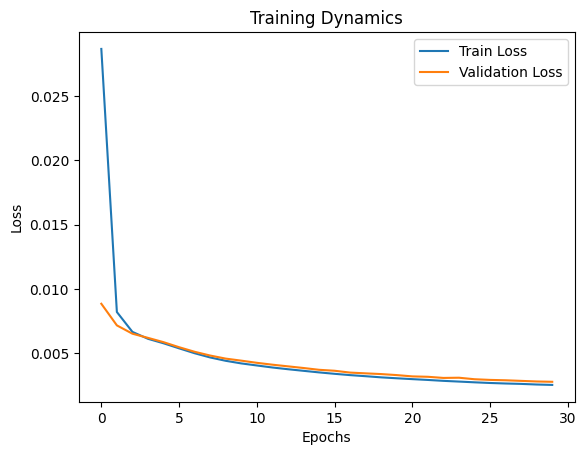

In [ ]:
# Training Dynamics Plot (“Loss convergence indicates stable training without divergence.”)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Dynamics")
plt.legend()
plt.show()

In [ ]:
# Latent Space Extraction
encoder_model = Model(inputs, latent)

latent_train = encoder_model.predict(X_train)
latent_test = encoder_model.predict(X_test)

230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


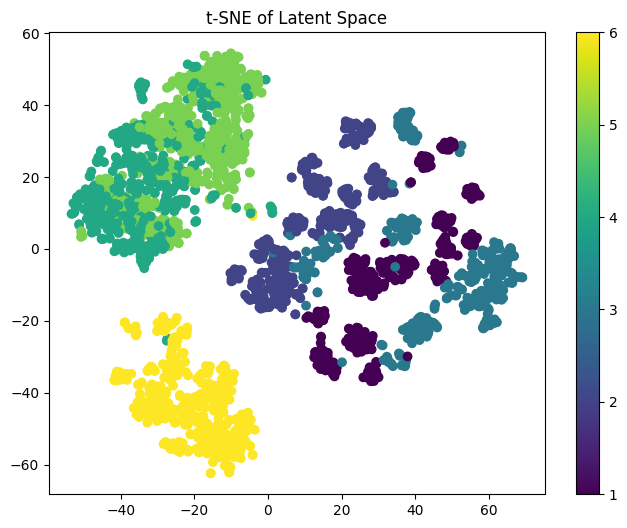

In [ ]:
# t-SNE Visualization
tsne = TSNE(n_components=2, random_state=42)
reduced = tsne.fit_transform(latent_test)

plt.figure(figsize=(8,6))
scatter = plt.scatter(reduced[:,0], reduced[:,1], c=y_test, cmap='viridis')
plt.colorbar(scatter)
plt.title("t-SNE of Latent Space")
plt.show()

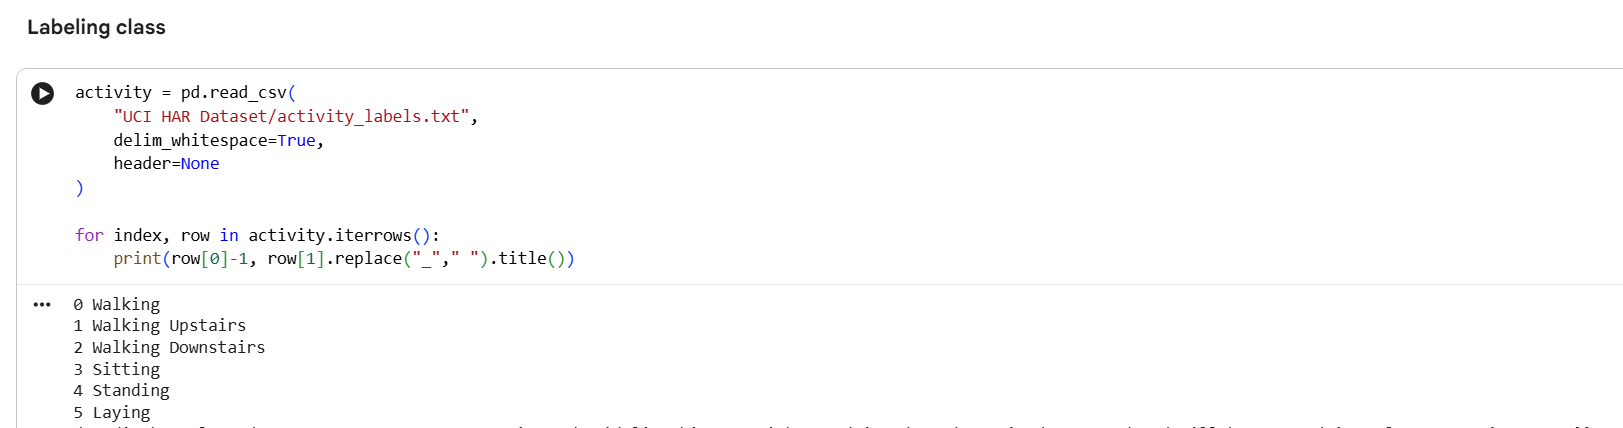

93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Average Reconstruction Error: 0.0027576436946429948


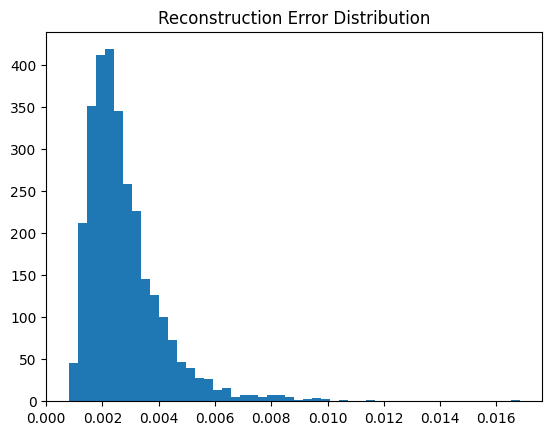

In [ ]:
# Reconstruction Quality
reconstructed = model.predict(X_test)

mse = np.mean(np.power(X_test - reconstructed, 2), axis=(1,2))

print("Average Reconstruction Error:", np.mean(mse))
plt.hist(mse, bins=50)
plt.title("Reconstruction Error Distribution")
plt.show()

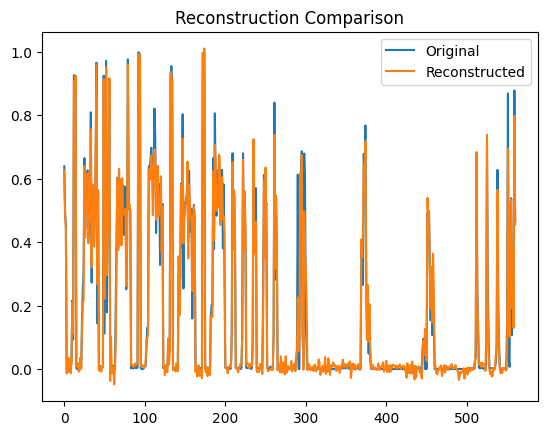

In [ ]:
# Visual Comparison
sample = 10

plt.plot(X_test[sample].flatten(), label='Original')
plt.plot(reconstructed[sample].flatten(), label='Reconstructed')
plt.legend()
plt.title("Reconstruction Comparison")
plt.show()

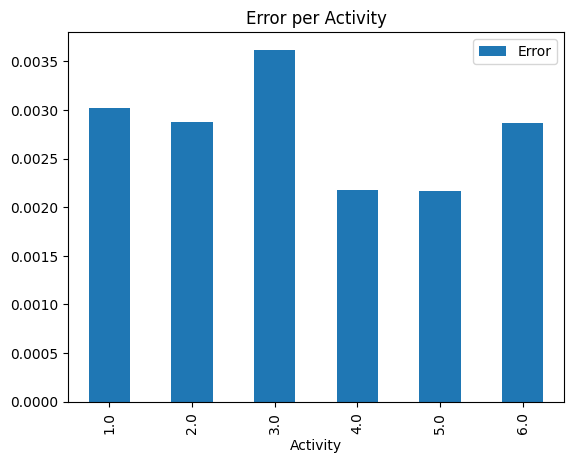

In [ ]:
# Activity-wise Error
import pandas as pd

df = pd.DataFrame({
    'Activity': y_test,
    'Error': mse
})

df.groupby('Activity').mean().plot(kind='bar')
plt.title("Error per Activity")
plt.show()
# 👉 Shows:

# Sitting = low error
# Walking = high variation

**Clean Modular Code**

In [ ]:
def build_model(timesteps, features):
    inputs = Input(shape=(timesteps, features))
    x = LSTM(128, activation='relu')(inputs)
    latent = Dense(64, activation='relu')(x)
    x = RepeatVector(timesteps)(latent)
    x = LSTM(128, activation='relu', return_sequences=True)(x)
    outputs = TimeDistributed(Dense(features))(x)
    return Model(inputs, outputs)



Train → Plot Loss
Encode → Plot t-SNE
Predict → Plot Reconstruction
Evaluate → Plot Errors
Compare → Plot Activity Graph
💬 How your notebook should flow
1. Load data
2. Preprocess
3. Build model
4. Train model
   → Loss graph
5. Encode latent
   → t-SNE
6. Predict
   → Reconstruction plot
7. Evaluate
   → Histogram + MSE
8. Compare
   → Bar + Box plots